# 相互インダクタンス

## PySpiceによる解析

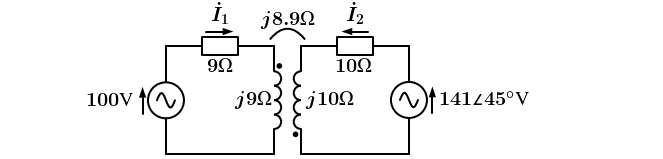

相互インダクタンスは結合係数の指定で$M$ および和動・差動を示せる．
```K1 L1 L2 -0.9381```は$L_1$と$L_2$の磁気的結合が結合係数$k=0.9381$で**差動**(負値)ということを意味する．

$$k = \frac{M}{\sqrt{L_1 L_2}}$$

で算出


In [2]:
import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from pprint import pprint

from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *
import matplotlib.pyplot as plt
import numpy as np
circuit = Circuit('test')
circuit.raw_spice = u'''V1 1 0 DC 0 AC 100 0
R1 1 2a 9
Vmeas_R1 2a 2 DC 0 AC 0 0
L1 2 0 9m
L2 3 0 10m
R2 3 4a 10
Vmeas_R2 4 4a DC 0 AC 0 0
V2 4 0 DC 0 AC 141 45
K1 L1 L2 -0.9381
'''
simulator = circuit.simulator(temperature=25, nominal_temperature=25)
res = simulator.ac(start_frequency=159.1549,stop_frequency=159.1549,number_of_points=1, variation='lin')
ir1 = np.array(res.branches['vmeas_r1'])
ir2 = np.array(res.branches['vmeas_r2'])
print('I1:',ir1,', I2:',ir2)


I1: [9.0150792+3.34071176j] , I2: [12.49518534+5.49807958j]
